FULL LIST OF REPEATED SOLUTIONS (18 Total Repeats Found)
 Word  1st Game #   1st Date  2nd Game #   2nd Date  Gap (Games)
cigar           0 2021-06-19        1689 2026-02-02         1689
awake           4 2021-06-23        1708 2026-02-21         1704
grade          15 2021-07-04        1730 2026-03-15         1715
linen          51 2021-08-09        1718 2026-03-03         1667
stand          57 2021-08-15        1765 2026-04-19         1708
ivory          59 2021-08-17        1742 2026-03-27         1683
stout          65 2021-08-23        1850 2026-07-13         1785
agree          70 2021-08-28        1797 2026-05-21         1727
thumb         115 2021-10-12        1814 2026-06-07         1699
comet         122 2021-10-19        1745 2026-03-30         1623
clock         160 2021-11-26        1788 2026-05-12         1628
bring         164 2021-11-30        1778 2026-05-02         1614
break         172 2021-12-08        1819 2026-06-12         1647
baton         183 2021-12-19     

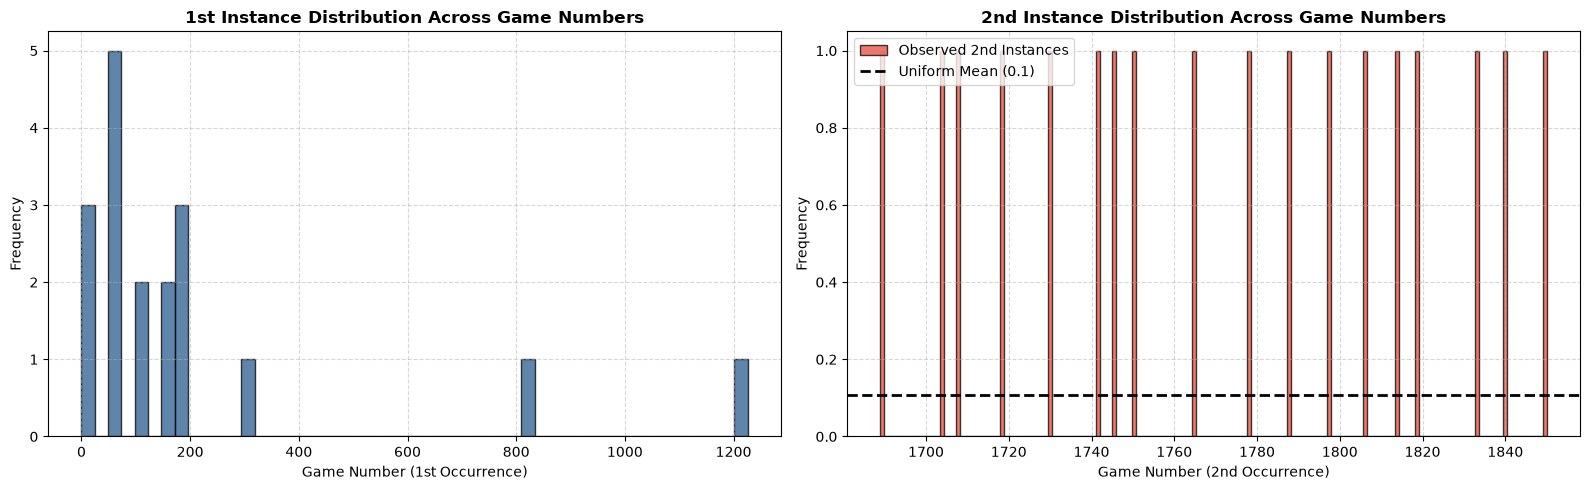

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data
df = pd.read_csv('../data/past_answers.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Track occurrence order for each solution word
df['occurrence'] = df.groupby('solution').cumcount() + 1

# Separate 1st and 2nd instances
inst1 = df[df['occurrence'] == 1].set_index('solution')
inst2 = df[df['occurrence'] == 2].set_index('solution')

# Join 1st and 2nd instances (filters for words that have repeated at least once)
repeats = inst1[['game_num', 'date']].join(
    inst2[['game_num', 'date']], 
    lsuffix='_1st', 
    rsuffix='_2nd', 
    how='inner'
).reset_index()

# Calculate gap in games between repeat instances
repeats['game_gap'] = repeats['game_num_2nd'] - repeats['game_num_1st']

# Format date strings for readable display
repeats['date_1st_str'] = repeats['date_1st'].dt.strftime('%Y-%m-%d')
repeats['date_2nd_str'] = repeats['date_2nd'].dt.strftime('%Y-%m-%d')

# 3. Print the full list of repeats
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=" * 80)
print(f"FULL LIST OF REPEATED SOLUTIONS ({len(repeats)} Total Repeats Found)")
print("=" * 80)
print(repeats[['solution', 'game_num_1st', 'date_1st_str', 'game_num_2nd', 'date_2nd_str', 'game_gap']]
      .rename(columns={
          'solution': 'Word',
          'game_num_1st': '1st Game #',
          'date_1st_str': '1st Date',
          'game_num_2nd': '2nd Game #',
          'date_2nd_str': '2nd Date',
          'game_gap': 'Gap (Games)'
      }).to_string(index=False))

# 4. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Graph 1: Distribution of 1st Instances ---
axes[0].hist(repeats['game_num_1st'], bins=50, color='#2b5c8f', edgecolor='black', alpha=0.75)
axes[0].set_title('1st Instance Distribution Across Game Numbers', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Game Number (1st Occurrence)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Graph 2: Distribution of 2nd Instances vs Uniform Expected ---
counts, bins, _ = axes[1].hist(
    repeats['game_num_2nd'], 
    bins=167, 
    color='#e74c3c', 
    edgecolor='black', 
    alpha=0.75, 
    label='Observed 2nd Instances'
)

# Reference line showing theoretical uniform average (expected if purely random/even distribution)
expected_even = len(repeats) / len(bins[:-1])
axes[1].axhline(expected_even, color='black', linestyle='--', linewidth=2, label=f'Uniform Mean ({expected_even:.1f})')

axes[1].set_title('2nd Instance Distribution Across Game Numbers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Game Number (2nd Occurrence)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import scipy.stats as stats

# Sort second instances by game number
gnum_2nd = np.sort(repeats['game_num_2nd'].values)

# Calculate gaps between consecutive repeat events
consecutive_gaps = np.diff(gnum_2nd)

# -------------------------------------------------------------
# TEST 1: EVEN SPACING / DISPERSION TEST (Coefficient of Variation)
# -------------------------------------------------------------
mean_gap = np.mean(consecutive_gaps)
std_gap = np.std(consecutive_gaps, ddof=1)
cv = std_gap / mean_gap

print("=" * 60)
print("1. INTER-ARRIVAL GAP SPACING TEST")
print("=" * 60)
print(f"Mean Gap Between Repeats : {mean_gap:.2f} games")
print(f"Std Dev of Gaps          : {std_gap:.2f} games")
print(f"Coefficient of Var (CV)  : {cv:.3f}")

if cv < 0.8:
    print("--> RESULT: Gaps are MORE EVENLY SPACED than pure random chance (CV < 1.0).")
elif cv > 1.2:
    print("--> RESULT: Repeats are CLUSTERED together (CV > 1.0).")
else:
    print("--> RESULT: Gap spacing is consistent with pure RANDOM CHANCE (CV ≈ 1.0).")

# -------------------------------------------------------------
# TEST 2: KOLMOGOROV-SMIRNOV TEST FOR UNIFORMITY
# -------------------------------------------------------------
# Set the evaluation window from the first repeat to the latest game played
min_g = gnum_2nd.min()
max_g = df['game_num'].max()

# Scale game numbers across the active repeat era
norm_gnum = (gnum_2nd - min_g) / (max_g - min_g)
ks_stat, ks_pvalue = stats.kstest(norm_gnum, 'uniform')

print("\n" + "=" * 60)
print("2. KOLMOGOROV-SMIRNOV UNIFORMITY TEST")
print("=" * 60)
print(f"KS Statistic : {ks_stat:.4f}")
print(f"p-value      : {ks_pvalue:.4f}")

if ks_pvalue < 0.05:
    print("--> RESULT: Reject Null Hypothesis. 2nd instances deviate significantly from uniform randomness.")
else:
    print("--> RESULT: Fail to reject Null Hypothesis. 2nd instances look uniformly random over time.")

# -------------------------------------------------------------
# TEST 3: EXPONENTIAL FIT TEST ON GAPS
# -------------------------------------------------------------
# If arrivals are Poisson, gaps must follow an Exponential distribution
gap_ks_stat, gap_pvalue = stats.kstest(consecutive_gaps, 'expon', args=(0, mean_gap))

print("\n" + "=" * 60)
print("3. EXPONENTIAL DISTRIBUTION GAP TEST")
print("=" * 60)
print(f"KS Statistic : {gap_ks_stat:.4f}")
print(f"p-value      : {gap_pvalue:.4f}")

if gap_pvalue < 0.05:
    print("--> RESULT: Gaps do NOT follow an exponential distribution (non-random spacing).")
else:
    print("--> RESULT: Gaps are consistent with a memoryless random process.")

1. INTER-ARRIVAL GAP SPACING TEST
Mean Gap Between Repeats : 9.47 games
Std Dev of Gaps          : 3.78 games
Coefficient of Var (CV)  : 0.399
--> RESULT: Gaps are MORE EVENLY SPACED than pure random chance (CV < 1.0).

2. KOLMOGOROV-SMIRNOV UNIFORMITY TEST
KS Statistic : 0.0979
p-value      : 0.9884
--> RESULT: Fail to reject Null Hypothesis. 2nd instances look uniformly random over time.

3. EXPONENTIAL DISTRIBUTION GAP TEST
KS Statistic : 0.2925
p-value      : 0.0877
--> RESULT: Gaps are consistent with a memoryless random process.
